# Model Selection In-Class Exercise

In this example, you will a linear model to data and select the model order by model order selection.  First load the standard packages.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Load the Data

The data in this exercise is completely synthetic.  You can load it with the following commmand.

In [2]:
fn_src = 'https://raw.githubusercontent.com/sdrangan/introml/master/unit04_model_sel/synth_data.p'
fn_dst = 'synth_data.p'

import os
from six.moves import urllib

if os.path.isfile(fn_dst):
    print('File %s is already downloaded' % fn_dst)
else:
    urllib.request.urlretrieve(fn_src, fn_dst)
    print('File %s downloaded' % fn_dst)

with open(fn_dst,'rb') as fp:
    x,y = pickle.load(fp)

File synth_data.p downloaded


Plot the data `y` vs. `x` using a scatter plot.

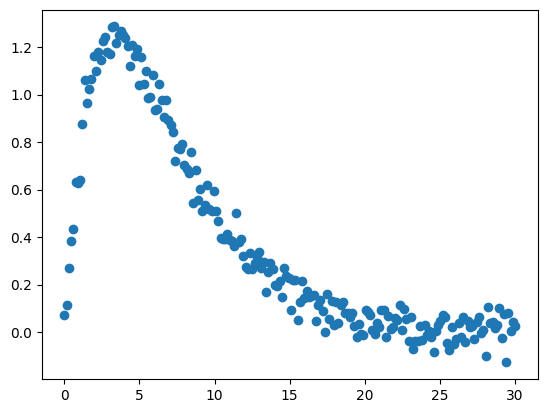

In [3]:
# TODO
plt.scatter(x,y)

## Fit the Data

We will now try to fit the data.  First, split the data into training and test.  You can use the `train_test_split()` method in the `sklearn` package.

In [11]:
# TODO
# xtr, xts, ytr, yts = train_test_split(...)
xtr,xts,ytr,yts = train_test_split(x,y,train_size=0.5)

Now try to fit a linear model to the data.  You can pick any linear model with a variable number `d` of basis functions.  For example, you can use the polynomials up to degree `d-1`.  

For each model order `d`:
* Fit the model on the training data
* Test the model on the test data

Plot the test error vs. `d`.  Select the model order `dopt` with the lowest test error.

Optimal order is 7


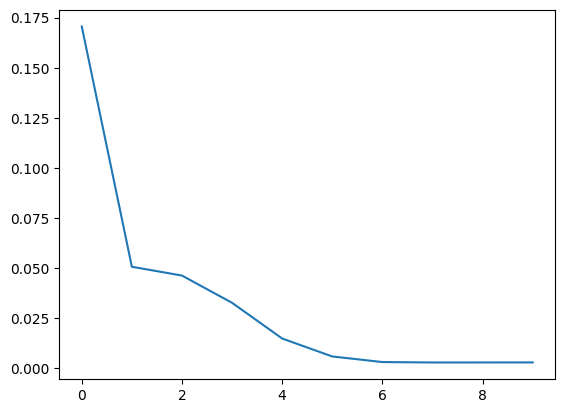

In [16]:
# TODO
import numpy.polynomial.polynomial as poly
dtest = np.array(range(10))
Rsstest = []

for d in dtest:
  beta_hat = poly.polyfit(xtr,ytr,d)
  yhat = poly.polyval(xts,beta_hat)
  Rssd= np.mean((yts-yhat)**2)
  Rsstest.append(Rssd)
plt.plot(dtest,Rsstest)

imin = np.argmin(Rsstest)
dopt = dtest[imin]
print('Optimal order is {0:d}'.format(dopt))

Select the optimal model order `dopt`.  Re-train the model for that model order.  On one plot:
* Plot the predicted value `yhat` vs. `x` for your model for `x in [0,35]`
* Plot a scatter plot of the test data `xts` vs. `yts`

Does your model fit the test data well?
Does it extrapolate reasonably in the range `x >= 30`?

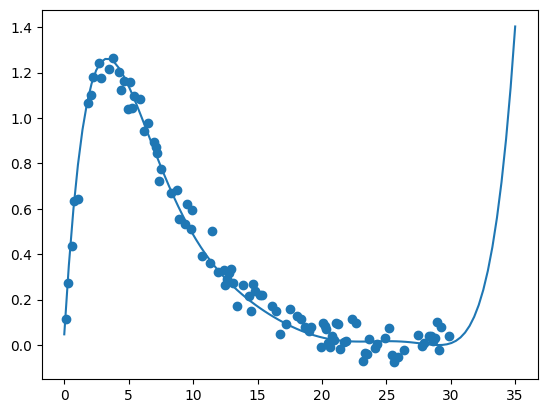

In [17]:
# TODO
beta_hat = poly.polyfit(xtr,ytr,dopt)
x = np.linspace(0,35,100)
yhat = poly.polyval(x,beta_hat)

plt.figure()
plt.plot(x,yhat)
plt.scatter(xts,yts)